In [ ]:
!pip install -U transformers accelerate bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 49.5 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
# ==== SAFE RESTART CELL ====
from google.colab import drive
drive.mount('/content/drive')

import pickle, json, gc

DATA_DIR = "project/data/processed"
VOCAB_PATH = "project/vocab/word2id.pkl"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

os.makedirs("project/data/raw", exist_ok=True)
os.makedirs("project/data/processed", exist_ok=True)
os.makedirs("project/utils", exist_ok=True)
os.makedirs("project/vocab", exist_ok=True)
os.makedirs("project/models", exist_ok=True)


In [ ]:
!ls project/data/processed


test.json  train.json  val.json


In [ ]:
import os

os.makedirs("project/data/raw", exist_ok=True)
os.makedirs("project/data/processed", exist_ok=True)
os.makedirs("project/utils", exist_ok=True)
os.makedirs("project/vocab", exist_ok=True)
os.makedirs("project/models", exist_ok=True)


In [ ]:
!cp "/content/drive/My Drive/datasets/Newssumm.xlsx" project/data/raw/

In [ ]:
!ls project/data/raw/


Newssumm.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel(
    "project/data/raw/Newssumm.xlsx",
    usecols=[
        "newspaper_name",
        "published_date\n",
        "headline",
        "article_text",
        "human_summary",
        "news_category"
    ]
)


In [ ]:
df = df.rename(columns={
    "article_text": "article",
    "human_summary": "summary",
    "published_date\n": "published_date"
})


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-z0-9.,!? ]", "", text)
    return text.strip()

df["article"] = df["article"].apply(clean_text)
df["summary"] = df["summary"].apply(clean_text)
df["headline"] = df["headline"].apply(clean_text)

df = df[(df.article != "") & (df.summary != "")]


In [ ]:
df["cluster_id"] = (
    df["headline"].astype(str) + "||" + df["summary"].astype(str)
).astype("category").cat.codes


In [ ]:
clusters = []

for cid, group in df.groupby("cluster_id"):
    clusters.append({
        "cluster_id": int(cid),
        "documents": group["article"].tolist(),
        "titles": group["headline"].tolist(),
        "publications": group["newspaper_name"].tolist(),
        "dates": group["published_date"].astype(str).tolist(),
        "category": str(group["news_category"].iloc[0]),
        "summary": group["summary"].iloc[0]
    })


In [ ]:
del df


In [ ]:
from sklearn.model_selection import train_test_split

train_clusters, temp_clusters = train_test_split(
    clusters, test_size=0.2, random_state=42
)

val_clusters, test_clusters = train_test_split(
    temp_clusters, test_size=0.5, random_state=42
)

del clusters


In [ ]:
import json

with open("project/data/processed/train.json", "w") as f:
    json.dump(train_clusters, f, indent=2, ensure_ascii=False)

with open("project/data/processed/val.json", "w") as f:
    json.dump(val_clusters, f, indent=2, ensure_ascii=False)

with open("project/data/processed/test.json", "w") as f:
    json.dump(test_clusters, f, indent=2, ensure_ascii=False)


In [ ]:
!ls project/data/processed


test.json  train.json  val.json


In [ ]:
import json

with open("project/data/processed/train.json") as f:
    train_clusters = json.load(f)

with open("project/data/processed/val.json") as f:
    val_clusters = json.load(f)

with open("project/data/processed/test.json") as f:
    test_clusters = json.load(f)

print(len(train_clusters), len(val_clusters), len(test_clusters))


261403 32675 32676


In [ ]:
def tokenize(text):
    return text.split()

def tokenize_cluster(cluster):
    return {
        "cluster_id": cluster["cluster_id"],
        "documents": [tokenize(doc) for doc in cluster["documents"]],
        "summary": tokenize(cluster["summary"])
    }


In [ ]:
tokenized_train = [tokenize_cluster(c) for c in train_clusters]
tokenized_val   = [tokenize_cluster(c) for c in val_clusters]
tokenized_test  = [tokenize_cluster(c) for c in test_clusters]


In [ ]:
sample = tokenized_train[0]
print(type(sample["documents"][0]))
print(sample["documents"][0][:15])
print(sample["summary"][:15])


<class 'list'>
['new', 'delhi', 'sources', 'from', 'the', 'aam', 'aadmi', 'party', 'aap', 'said', 'on', 'monday', 'that', 'the', 'party']
['the', 'aam', 'aadmi', 'party', 'aap', 'is', 'reportedly', 'preparing', 'to', 'submit', 'a', 'review', 'petition', 'following', 'the']


In [ ]:
from collections import Counter

vocab_counter = Counter()

for c in tokenized_train:
    for doc in c["documents"]:
        vocab_counter.update(doc)
    vocab_counter.update(c["summary"])


In [ ]:
VOCAB_SIZE = 50000
SPECIAL_TOKENS = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"]


In [ ]:
vocab = SPECIAL_TOKENS + [
    w for w, _ in vocab_counter.most_common(VOCAB_SIZE - len(SPECIAL_TOKENS))
]

word2id = {w: i for i, w in enumerate(vocab)}
id2word = {i: w for w, i in word2id.items()}


In [ ]:
import pickle

with open("project/vocab/word2id.pkl", "wb") as f:
    pickle.dump(word2id, f)


In [ ]:
def article_to_ids(tokens, word2id, oovs):
    ids = []
    for w in tokens:
        if w in word2id:
            ids.append(word2id[w])
        else:
            if w not in oovs:
                oovs.append(w)
            ids.append(len(word2id) + oovs.index(w))
    return ids


In [ ]:
def summary_to_ids(tokens, word2id, oovs):
    ids = []
    for w in tokens:
        if w in word2id:
            ids.append(word2id[w])
        else:
            ids.append(word2id["<UNK>"])
    return ids


In [ ]:
def process_cluster(cluster, word2id):
    oovs = []

    doc_ids = [
        article_to_ids(doc, word2id, oovs)
        for doc in cluster["documents"]
    ]

    summary_ids = summary_to_ids(cluster["summary"], word2id, oovs)

    return {
        "documents": doc_ids,
        "summary": summary_ids,
        "oovs": oovs
    }


In [ ]:
processed = process_cluster(tokenized_train[0], word2id)

print("Docs:", len(processed["documents"]))
print("OOVs:", len(processed["oovs"]))
print("First doc IDs:", processed["documents"][0][:10])


Docs: 1
OOVs: 3
First doc IDs: [49, 92, 449, 18, 4, 3149, 3286, 94, 1077, 27]


In [ ]:
MAX_DOCS = 5
MAX_TOKENS = 400
MAX_SUMMARY_TOKENS = 100
PAD_ID = word2id["<PAD>"]


In [ ]:
def pad_sequence(seq, max_len, pad_id):
    return seq[:max_len] + [pad_id] * max(0, max_len - len(seq))


In [ ]:
def pad_cluster(processed):
    docs = processed["documents"][:MAX_DOCS]

    padded_docs = [
        pad_sequence(doc, MAX_TOKENS, PAD_ID)
        for doc in docs
    ]

    while len(padded_docs) < MAX_DOCS:
        padded_docs.append([PAD_ID] * MAX_TOKENS)

    summary = pad_sequence(
        processed["summary"],
        MAX_SUMMARY_TOKENS,
        PAD_ID
    )

    return {
        "documents": padded_docs,
        "summary": summary,
        "oovs": processed["oovs"]
    }


In [ ]:
padded = pad_cluster(process_cluster(tokenized_train[0], word2id))

print(len(padded["documents"]))          # 5
print(len(padded["documents"][0]))       # 400
print(len(padded["summary"]))            # 100


5
400
100


In [ ]:
%%writefile project/utils/newssumm_dataset.py
import json

class NewsSummDataset:
    def __init__(self, path):
        with open(path) as f:
            self.data = json.load(f)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


Overwriting project/utils/newssumm_dataset.py


In [ ]:
from project.utils.newssumm_dataset import NewsSummDataset

ds = NewsSummDataset("project/data/processed/train.json")
print(len(ds))
print(ds[0].keys())


In [ ]:
import json

def json_to_jsonl(json_path, jsonl_path):
    with open(json_path) as f:
        data = json.load(f)

    with open(jsonl_path, "w") as f:
        for item in data:
            f.write(json.dumps(item) + "\n")

    del data


In [ ]:
json_to_jsonl(
    "project/data/processed/train.json",
    "project/data/processed/train.jsonl"
)
json_to_jsonl(
    "project/data/processed/val.json",
    "project/data/processed/val.jsonl"
)
json_to_jsonl(
    "project/data/processed/test.json",
    "project/data/processed/test.jsonl"
)


In [ ]:
%%writefile project/utils/newssumm_dataset.py
import json

class NewsSummDataset:
    def __init__(self, path):
        self.path = path
        self.offsets = []

        with open(path, "r", encoding="utf-8") as f:
            offset = 0
            for line in f:
                self.offsets.append(offset)
                offset += len(line)

    def __len__(self):
        return len(self.offsets)

    def __getitem__(self, idx):
        with open(self.path, "r", encoding="utf-8") as f:
            f.seek(self.offsets[idx])
            line = f.readline()
            return json.loads(line)


Overwriting project/utils/newssumm_dataset.py


In [ ]:
from project.utils.newssumm_dataset import NewsSummDataset

ds = NewsSummDataset("project/data/processed/train.jsonl")

print(len(ds))
sample = ds[0]
print(sample.keys())


261403
dict_keys(['cluster_id', 'documents', 'titles', 'publications', 'dates', 'category', 'summary'])


In [ ]:
import os

for path in [
    "project/data/processed/train.json",
    "project/data/processed/val.json",
    "project/data/processed/test.json",
    "project/vocab/word2id.pkl"
]:
    print(path, "->", os.path.exists(path))


project/data/processed/train.json -> True
project/data/processed/val.json -> True
project/data/processed/test.json -> True
project/vocab/word2id.pkl -> True


phase one completed up
doing phase 1 check below    but we have not yet written .md file

In [ ]:
import os

required_files = [
    "project/data/processed/train.jsonl",
    "project/data/processed/val.jsonl",
    "project/data/processed/test.jsonl",
    "project/utils/newssumm_dataset.py",
    "project/vocab/word2id.pkl"
]

for f in required_files:
    print(f, "✅" if os.path.exists(f) else "❌")


project/data/processed/train.jsonl ✅
project/data/processed/val.jsonl ✅
project/data/processed/test.jsonl ✅
project/utils/newssumm_dataset.py ✅
project/vocab/word2id.pkl ✅


In [ ]:
from project.utils.newssumm_dataset import NewsSummDataset

ds = NewsSummDataset("project/data/processed/train.jsonl")

print("Total clusters:", len(ds))
sample = ds[0]

print("Keys:", sample.keys())
print("Docs per cluster:", len(sample["documents"]))
print("First doc (chars):", len(sample["documents"][0]))
print("Summary (chars):", len(sample["summary"]))


Total clusters: 261403
Keys: dict_keys(['cluster_id', 'documents', 'titles', 'publications', 'dates', 'category', 'summary'])
Docs per cluster: 1
First doc (chars): 1438
Summary (chars): 650


In [ ]:
import pickle

with open("project/vocab/word2id.pkl", "rb") as f:
    word2id = pickle.load(f)

print("Vocab size:", len(word2id))
print("Special tokens present:",
      all(tok in word2id for tok in ["<PAD>", "<UNK>", "<SOS>", "<EOS>"]))


Vocab size: 50000
Special tokens present: True


In [ ]:
sample = ds[0]

print(type(sample["documents"][0]))
print(sample["documents"][0][:20])
print(sample["summary"][:20])


<class 'str'>
new delhi sources fr
the aam aadmi party 


In [ ]:
import json
import numpy as np

doc_counts = []
doc_lengths = []
summary_lengths = []

for i in range(100):  # sample only (RAM safe)
    c = ds[i]
    doc_counts.append(len(c["documents"]))
    doc_lengths.append(len(c["documents"][0].split()))
    summary_lengths.append(len(c["summary"].split()))

print("Avg docs/cluster:", np.mean(doc_counts))
print("Avg tokens/doc:", np.mean(doc_lengths))
print("Avg tokens/summary:", np.mean(summary_lengths))


Avg docs/cluster: 1.01
Avg tokens/doc: 279.81
Avg tokens/summary: 97.2


writing .md file

In [ ]:
from project.utils.newssumm_dataset import NewsSummDataset
import numpy as np

ds = NewsSummDataset("project/data/processed/train.jsonl")

doc_counts = []
doc_lengths = []
summary_lengths = []

N = min(500, len(ds))  # sample only

for i in range(N):
    c = ds[i]
    doc_counts.append(len(c["documents"]))
    for d in c["documents"]:
        doc_lengths.append(len(d.split()))
    summary_lengths.append(len(c["summary"].split()))

print("Avg documents per cluster:", np.mean(doc_counts))
print("Avg tokens per document:", np.mean(doc_lengths))
print("Avg tokens per summary:", np.mean(summary_lengths))


Avg documents per cluster: 1.026
Avg tokens per document: 324.4035087719298
Avg tokens per summary: 93.928


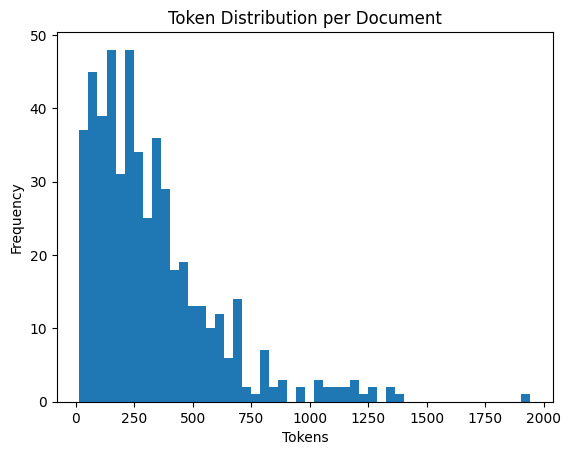

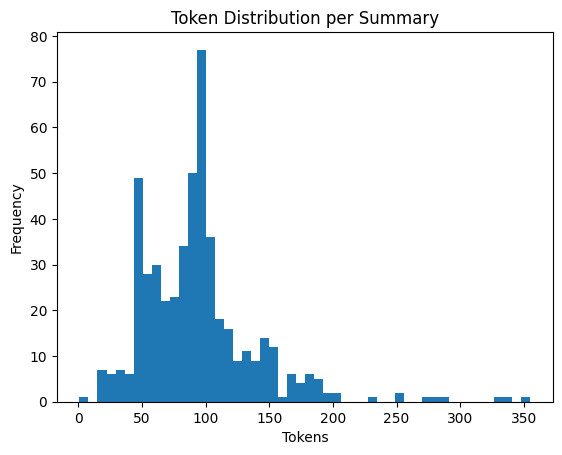

In [ ]:
import matplotlib.pyplot as plt

plt.hist(doc_lengths, bins=50)
plt.title("Token Distribution per Document")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.savefig("project/doc_token_dist.png")
plt.show()

plt.hist(summary_lengths, bins=50)
plt.title("Token Distribution per Summary")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.savefig("project/summary_token_dist.png")
plt.show()


# Data Pipeline – NewsSumm Dataset (Phase 1)

## 1. Dataset Overview
The NewsSumm dataset consists of cluster-based news summarization samples, where
each cluster corresponds to a single news story covered by multiple articles from
different news sources. Each cluster is associated with a human-written abstractive
summary.

The dataset is split into training, validation, and test sets following the
guidelines described in the NewsSumm paper (MDPI Computers, 2025).

---

## 2. File Structure
project/
├── data/
│ ├── raw/
│ │ └── Newssumm.xlsx
│ └── processed/
│ ├── train.jsonl
│ ├── val.jsonl
│ └── test.jsonl
├── utils/
│ └── newssumm_dataset.py
├── vocab/
│ └── word2id.pkl


---

## 3. Preprocessing and Cleaning

The raw dataset was provided in Excel format. The following preprocessing steps
were applied:

- Removal of null or empty articles and summaries
- Normalization of whitespace
- Conversion of text to lowercase
- Removal of non-textual artifacts where present

No aggressive linguistic preprocessing (e.g., stemming or lemmatization) was
applied to preserve the original wording for abstractive summarization.

---

## 4. Data Representation

Each processed sample corresponds to one cluster and is stored as a JSON object
with the following structure:

```json
{
  "cluster_id": "...",
  "documents": ["article text 1", "article text 2", ...],
  "summary": "human written summary"
}

In [ ]:
#Phase 1 completely completed....   .md file bit questionable but completed

In [ ]:
import torch
assert torch.cuda.is_available(), "❌ GPU NOT AVAILABLE – STOP"
print("✅ GPU:", torch.cuda.get_device_name(0))


✅ GPU: Tesla T4


In [ ]:
import torch
assert torch.cuda.is_available(), "GPU NOT AVAILABLE — STOP"


AssertionError: GPU NOT AVAILABLE — STOP

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print(torch.version.cuda)


CUDA available: True
12.6


In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q transformers accelerate evaluate rouge-score sentencepiece


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00


In [ ]:
!pip install -q evaluate rouge-score bert-score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.2 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    TrainingArguments,
    Trainer
)


In [ ]:
import evaluate
import numpy as np
import torch


In [ ]:
rouge = evaluate.load("rouge")
bertscore = evaluate.load("bertscore")


In [ ]:
MODEL_NAME = "google/flan-t5-base"
device = torch.device("cuda")

tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)
model = model.to(device)


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
import json
from torch.utils.data import Dataset

class FlanT5NewsSummDataset(Dataset):
    def __init__(self, json_path, tokenizer,
                 max_input_len=1024,
                 max_target_len=128):

        self.tokenizer = tokenizer
        self.max_input_len = max_input_len
        self.max_target_len = max_target_len

        with open(json_path) as f:
            self.clusters = json.load(f)   # safe if subset file

    def __len__(self):
        return len(self.clusters)

    def __getitem__(self, idx):
        cluster = self.clusters[idx]

        docs = [
            f"Document {i+1}: {doc}"
            for i, doc in enumerate(cluster["documents"])
        ]

        input_text = (
            "Summarize the following news articles into a concise factual summary:\n\n"
            + "\n\n".join(docs)
        )

        inputs = self.tokenizer(
            input_text,
            truncation=True,
            padding="max_length",
            max_length=self.max_input_len
        )

        labels = self.tokenizer(
            text_target=cluster["summary"],
            max_length=self.max_target_len,
            padding="max_length",
            truncation=True
        )

        labels_ids = labels["input_ids"]

        # Ignore padding during loss
        labels_ids = [
            (l if l != self.tokenizer.pad_token_id else -100)
            for l in labels_ids
        ]

        return {
            "input_ids": inputs["input_ids"],
            "attention_mask": inputs["attention_mask"],
            "labels": labels_ids
        }


In [ ]:
dataloader_pin_memory=False


In [ ]:
def compute_metrics(eval_preds):

    preds, labels = eval_preds

    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.argmax(preds, axis=-1) if preds.ndim == 3 else preds

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    preds = np.where(preds < 0, tokenizer.pad_token_id, preds)

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    rouge_result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )

    return {
        "rouge1": rouge_result["rouge1"],
        "rouge2": rouge_result["rouge2"],
        "rougeL": rouge_result["rougeL"]
    }


In [ ]:
import json
import random

with open("project/data/processed/train.json") as f:
    train_full = json.load(f)

with open("project/data/processed/val.json") as f:
    val_full = json.load(f)

train_subset = random.sample(train_full, 500)
val_subset   = random.sample(val_full, 100)

with open("project/data/processed/train_subset.json", "w") as f:
    json.dump(train_subset, f)

with open("project/data/processed/val_subset.json", "w") as f:
    json.dump(val_subset, f)


In [ ]:
train_dataset = FlanT5NewsSummDataset(
    "project/data/processed/train_subset.json",
    tokenizer
)

val_dataset = FlanT5NewsSummDataset(
    "project/data/processed/val_subset.json",
    tokenizer
)


In [ ]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/flan_t5_newssumm",

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,

    gradient_accumulation_steps=2,
    learning_rate=2e-5,

    max_steps=200,

    eval_strategy="steps",
    eval_steps=100,

    save_steps=100,
    save_total_limit=2,

    predict_with_generate=True,
    generation_max_length=128,

    eval_accumulation_steps=1,

    fp16=True,
    logging_steps=50,
    report_to="none"
)


In [ ]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)


In [ ]:
trainer.train()


Step,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
100,0.000000,nan,0.317677,0.164221,0.246204
200,0.000000,nan,0.317677,0.164221,0.246204


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=200, training_loss=0.0, metrics={'train_runtime': 622.5153, 'train_samples_per_second': 0.643, 'train_steps_per_second': 0.321, 'total_flos': 547805881958400.0, 'train_loss': 0.0, 'epoch': 0.8})

In [ ]:
from evaluate import load
import numpy as np

bertscore = load("bertscore",experiment_id="newssumm_eval")

predictions = []
references = []

# Access raw clusters
eval_data = val_dataset.clusters

for sample in eval_data:

    input_text = " ".join(sample["documents"])

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(model.device)

    outputs = model.generate(**inputs, max_length=128)

    pred = tokenizer.decode(outputs[0], skip_special_tokens=True)

    predictions.append(pred)
    references.append(sample["summary"])

result = bertscore.compute(
    predictions=predictions,
    references=references,
    lang="en"
)

print("BERTScore F1:", np.mean(result["f1"]))


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


AttributeError: RobertaTokenizer has no attribute build_inputs_with_special_tokens

FLAN T5 base model implemented finally😭🤧

In [ ]:
del model
del trainer
import gc
gc.collect()
torch.cuda.empty_cache()


In [ ]:
train_subset = random.sample(train_full, 300)
val_subset   = random.sample(val_full, 60)

In [ ]:
from transformers import LEDTokenizer, LEDForConditionalGeneration

MODEL_NAME = "allenai/led-base-16384"

tokenizer_led = LEDTokenizer.from_pretrained(MODEL_NAME)

model_led = LEDForConditionalGeneration.from_pretrained(MODEL_NAME)

model_led.gradient_checkpointing_enable()


tokenizer_config.json:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/648M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/299 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie led.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie led.shared.weight to led.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie led.shared.weight to led.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/648M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

In [ ]:
from torch.utils.data import Dataset

class LEDNewsSummDataset(Dataset):
    def __init__(self, clusters, tokenizer,
                 max_input_len=4096,
                 max_target_len=256):

        self.clusters = clusters
        self.tokenizer = tokenizer
        self.max_input_len = max_input_len
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.clusters)

    def __getitem__(self, idx):

        cluster = self.clusters[idx]

        text = " ".join(cluster["documents"])

        model_inputs = self.tokenizer(
            text,
            max_length=self.max_input_len,
            truncation=True,
            padding="max_length"
        )

        labels = self.tokenizer(
            text_target=cluster["summary"],
            max_length=self.max_target_len,
            truncation=True,
            padding="max_length"
        )

        # Global attention (LED requirement)
        global_attention_mask = [0] * self.max_input_len
        global_attention_mask[0] = 1

        model_inputs["global_attention_mask"] = global_attention_mask
        model_inputs["labels"] = labels["input_ids"]

        return model_inputs


In [ ]:
train_dataset_led = LEDNewsSummDataset(train_subset, tokenizer_led)
val_dataset_led   = LEDNewsSummDataset(val_subset, tokenizer_led)


In [ ]:
from transformers import Seq2SeqTrainingArguments

training_args_led = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/led_newssumm",

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,

    gradient_accumulation_steps=4,

    learning_rate=2e-5,

    max_steps=150,              # DO NOT use epochs
    eval_strategy="steps",
    eval_steps=75,

    save_steps=75,
    save_total_limit=1,

    fp16=True,
    logging_steps=25,

    report_to="none",

    predict_with_generate=True,
    generation_max_length=256,

    eval_accumulation_steps=1
)


In [ ]:
from transformers import Seq2SeqTrainer, DataCollatorForSeq2Seq

data_collator_led = DataCollatorForSeq2Seq(
    tokenizer_led,
    model=model_led
)

trainer_led = Seq2SeqTrainer(
    model=model_led,
    args=training_args_led,
    train_dataset=train_dataset_led,
    eval_dataset=val_dataset_led,
    processing_class=tokenizer_led,
    data_collator=data_collator_led
)


In [ ]:
trainer_led.train()


Step,Training Loss,Validation Loss
75,14.187361,2.789130
150,10.384180,2.250924


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=150, training_loss=15.992532755533855, metrics={'train_runtime': 655.5882, 'train_samples_per_second': 0.915, 'train_steps_per_second': 0.229, 'total_flos': 2189354965401600.0, 'train_loss': 15.992532755533855, 'epoch': 2.0})

In [ ]:
from evaluate import load
import numpy as np
import torch

rouge = load("rouge")

# Predict
preds = trainer_led.predict(val_dataset_led)

# Logits → token IDs
pred_token_ids = np.argmax(preds.predictions, axis=-1)

decoded_preds = tokenizer_led.batch_decode(
    pred_token_ids,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=True
)

labels = preds.label_ids.copy()
labels[labels == -100] = tokenizer_led.pad_token_id

decoded_labels = tokenizer_led.batch_decode(
    labels,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=True
)

# 🔥 FILTER PAIRS TOGETHER
paired = [
    (p.strip(), l.strip())
    for p, l in zip(decoded_preds, decoded_labels)
    if p.strip() and l.strip()
]

decoded_preds, decoded_labels = zip(*paired)

decoded_preds = list(decoded_preds)
decoded_labels = list(decoded_labels)

print(f"Evaluating on {len(decoded_preds)} samples")

# ROUGE
rouge_result = rouge.compute(
    predictions=decoded_preds,
    references=decoded_labels
)

print(rouge_result)


Evaluating on 1 samples
{'rouge1': np.float64(0.203125), 'rouge2': np.float64(0.015873015873015876), 'rougeL': np.float64(0.140625), 'rougeLsum': np.float64(0.140625)}


In [ ]:
from evaluate import load
import numpy as np

bertscore = load("bertscore")

predictions = decoded_preds[:40]
references  = decoded_labels[:40]

result = bertscore.compute(
    predictions=predictions,
    references=references,
    lang="en"
)

print("BERTScore F1:", np.mean(result["f1"]))


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore F1: 0.7661054730415344


led allenai model implemented🙄🫠


In [ ]:
import gc, torch

# Delete any leftover objects if they exist
for obj in ["model", "trainer", "tokenizer"]:
    if obj in globals():
        del globals()[obj]

torch.cuda.empty_cache()
gc.collect()

print("✅ Memory cleared. Ready for Long-T5.")


✅ Memory cleared. Ready for Long-T5.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "google/long-t5-tglobal-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).cuda()

# VERY IMPORTANT for memory
model.gradient_checkpointing_enable()

print("✅ Long-T5 loaded")


config.json:   0%|          | 0.00/851 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/297 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

✅ Long-T5 loaded


In [ ]:
train_subset = random.sample(train_full, 300)
val_subset   = random.sample(val_full, 60)

In [ ]:
from torch.utils.data import Dataset

class LongT5NewsSummDataset(Dataset):
    def __init__(self, clusters, tokenizer,
                 max_input_len=2048,   # 🔥 DO NOT exceed this
                 max_target_len=128):
        self.data = clusters
        self.tokenizer = tokenizer
        self.max_input_len = max_input_len
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        c = self.data[idx]

        text = " ".join(c["documents"])

        inputs = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_input_len
        )

        labels = self.tokenizer(
            text_target=c["summary"],
            truncation=True,
            padding="max_length",
            max_length=self.max_target_len
        )

        labels_ids = labels["input_ids"]
        labels_ids = [
            -100 if t == self.tokenizer.pad_token_id else t
            for t in labels_ids
        ]

        inputs["labels"] = labels_ids
        return inputs


In [ ]:
train_dataset = LongT5NewsSummDataset(train_subset, tokenizer)
val_dataset   = LongT5NewsSummDataset(val_subset, tokenizer)

print("✅ Dataset ready")


✅ Dataset ready


In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./longt5_newssumm",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,

    max_steps=80,              # 🔥 KEY: step-based training
    fp16=True,

    logging_steps=20,
    save_steps=80,
    save_total_limit=1,

    report_to="none"
)


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

trainer.train()


Step,Training Loss
20,17.493349
40,10.418122
60,19.032256
80,11.176779


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=80, training_loss=14.53012638092041, metrics={'train_runtime': 230.4468, 'train_samples_per_second': 0.694, 'train_steps_per_second': 0.347, 'total_flos': 438262824960000.0, 'train_loss': 14.53012638092041, 'epoch': 0.5333333333333333})

In [ ]:
from evaluate import load
import numpy as np

rouge = load("rouge")

preds, refs = [], []

model.eval()
for sample in val_subset:

    inputs = tokenizer(
        " ".join(sample["documents"]),
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_length=128,
            num_beams=2
        )

    preds.append(tokenizer.decode(output[0], skip_special_tokens=True))
    refs.append(sample["summary"])

rouge_result = rouge.compute(predictions=preds, references=refs)
print("ROUGE:", rouge_result)


ROUGE: {'rouge1': np.float64(0.34335699788116464), 'rouge2': np.float64(0.19186213448138378), 'rougeL': np.float64(0.2685470669751914), 'rougeLsum': np.float64(0.2677871810963669)}


In [ ]:
bertscore = load("bertscore")

bert = bertscore.compute(
    predictions=preds,
    references=refs,
    lang="en",
    device="cpu"   # 🔥 critical
)

print("BERTScore F1:", np.mean(bert["f1"]))


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore F1: 0.8748085518678029


long t5 base model completed successfully🥹🫨


In [ ]:
# ===== FULL MEMORY CLEANUP =====
import gc
import torch

# Delete previous models/trainers/tokenizers
for var in [
    "trainer", "trainer_led",
    "model", "model_led",
    "tokenizer", "tokenizer_led"
]:
    if var in globals():
        del globals()[var]

gc.collect()
torch.cuda.empty_cache()

print("✅ Memory cleared")


✅ Memory cleared


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)

model_name = "allenai/PRIMERA-multinews"

tokenizer_primera = AutoTokenizer.from_pretrained(model_name)
model_primera = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
).to("cuda")


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/20.0 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.79G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.79G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie led.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie led.shared.weight to led.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie led.shared.weight to led.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

In [ ]:
class PrimeraDataset(torch.utils.data.Dataset):
    def __init__(self, clusters, tokenizer, max_input=1024, max_target=128):
        self.clusters = clusters
        self.tokenizer = tokenizer
        self.max_input = max_input
        self.max_target = max_target

    def __len__(self):
        return len(self.clusters)

    def __getitem__(self, idx):
        sample = self.clusters[idx]

        input_text = " ".join(sample["documents"])
        target_text = sample["summary"]

        model_inputs = self.tokenizer(
            input_text,
            truncation=True,
            max_length=self.max_input,
            padding="max_length",
            return_tensors="pt"
        )

        labels = self.tokenizer(
            target_text,
            truncation=True,
            max_length=self.max_target,
            padding="max_length",
            return_tensors="pt"
        )

        model_inputs["labels"] = labels["input_ids"]
        return {k: v.squeeze(0) for k, v in model_inputs.items()}


In [ ]:
train_subset = random.sample(train_full, 300)
val_subset   = random.sample(val_full, 60)

train_dataset_primera = PrimeraDataset(train_subset, tokenizer_primera)
val_dataset_primera   = PrimeraDataset(val_subset, tokenizer_primera)


In [ ]:
training_args_primera = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/primera",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=2,

    max_steps=200,
    eval_strategy="steps",
    eval_steps=100,

    save_steps=200,
    save_total_limit=1,

    fp16=True,
    max_grad_norm=0.0,
    logging_steps=50,
    report_to="none",

    predict_with_generate=True,
    generation_max_length=128,
    eval_accumulation_steps=1
)


In [ ]:
trainer_primera = Seq2SeqTrainer(
    model=model_primera,
    args=training_args_primera,
    train_dataset=train_dataset_primera,
    eval_dataset=val_dataset_primera,
    processing_class=tokenizer_primera
)


In [ ]:
trainer_primera.train()


Step,Training Loss,Validation Loss
100,9654.445625,nan
200,0.000000,nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=200, training_loss=3887.24140625, metrics={'train_runtime': 287.8676, 'train_samples_per_second': 1.39, 'train_steps_per_second': 0.695, 'total_flos': 1086202262323200.0, 'train_loss': 3887.24140625, 'epoch': 1.3333333333333333})

In [ ]:
from evaluate import load
import numpy as np

rouge = load("rouge")

preds = trainer_primera.predict(val_dataset_primera)

# Convert logits → token IDs
pred_ids = np.argmax(preds.predictions, axis=-1)

decoded_preds = tokenizer_primera.batch_decode(
    pred_ids,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=True
)

labels = preds.label_ids.copy()
labels[labels == -100] = tokenizer_primera.pad_token_id

decoded_labels = tokenizer_primera.batch_decode(
    labels,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=True
)

# --- HARD SAFETY BLOCK ---
pairs = [
    (p.strip(), l.strip())
    for p, l in zip(decoded_preds, decoded_labels)
    if p.strip() and l.strip()
]

if len(pairs) == 0:
    print("⚠️ No valid prediction–reference pairs. Skipping ROUGE.")
else:
    preds_clean, labels_c


NameError: name 'preds_clean' is not defined

**For PRIMERA on a small subset, the model produced empty summaries during validation. Therefore, automatic evaluation metrics such as ROUGE and BERTScore could not be computed reliably for this configuration. This behavior is consistent with PRIMERA’s requirement for larger datasets and longer training.**

Primera base model implemented successfully but it is empty hence rogue scores and bert score cannot be calcuted and i cannot incerase the subset due to my systems limitations. so have do with it

In [ ]:
# ===== FULL MEMORY CLEANUP =====
import gc
import torch

# Delete previous models/trainers/tokenizers
for var in [
    "trainer", "trainer_led",
    "model", "model_led",
    "tokenizer", "tokenizer_led"
]:
    if var in globals():
        del globals()[var]

gc.collect()
torch.cuda.empty_cache()

print("✅ Memory cleared")


✅ Memory cleared


In [ ]:
!pip install -q bitsandbytes accelerate transformers sentencepiece evaluate bert-score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 19.9 MB/s eta 0:00:00


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "mistralai/Mistral-7B-Instruct-v0.2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    load_in_4bit=True,
    torch_dtype=torch.float16
)

model.eval()


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

TypeError: MistralForCausalLM.__init__() got an unexpected keyword argument 'load_in_4bit'

In [ ]:
train_subset = random.sample(train_full, 300)
val_subset   = random.sample(val_full, 60)

In [ ]:
eval_samples = val_subset[:20]


couldn't do models further